# BÀI TẬP THỰC HÀNH CHƯƠNG 3
## Nén ảnh

---

## 📁 Cấu trúc thư mục

```
chapter_3_lab/
├── images/              # Ảnh đầu vào
├── output/              # Kết quả xử lý
└── chapter_3_lab.ipynb  # File notebook (đặt trực tiếp ở thư mục ngoài)
```

---

## ⚙️ 0. Chuẩn bị môi trường

**Cell 0 — Khởi tạo chung (chạy đầu tiên trong notebook):**

In [1]:
%matplotlib inline

import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import data
import heapq
from collections import Counter

Path("images").mkdir(exist_ok=True)
Path("output").mkdir(exist_ok=True)

print("OpenCV version:", cv2.__version__)
print("NumPy version :", np.__version__)

# ---------- Hàm tiện ích hiển thị ảnh ----------
def show_image(img, title="", cmap=None, figsize=(5, 4), save_path=None):
    plt.figure(figsize=figsize)
    if img.ndim == 3:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title)
    plt.axis('off')
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()


def show_grid(images, titles, ncols=3, figsize=(15, 8),
              cmap='gray', save_path=None, main_title=None):
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).ravel()
    for i, (im, t) in enumerate(zip(images, titles)):
        ax = axes[i]
        if im.ndim == 3:
            ax.imshow(im)
        else:
            ax.imshow(im, cmap=cmap)
        ax.set_title(t, fontsize=10)
        ax.axis('off')
    for j in range(n, len(axes)):
        axes[j].axis('off')
    if main_title:
        plt.suptitle(main_title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

OpenCV version: 5.0.0
NumPy version : 2.5.3


> **Lưu ý:** Không dùng `cv2.imshow` / `cv2.waitKey` để tránh treo kernel.

---

## Bài 1: Tính Entropy của ảnh

**Mức độ:** Cơ bản

**Mục tiêu:** Áp dụng công thức `H = -Σ p(r_k) log₂ p(r_k)` để đo lượng tin trung bình của ảnh.

**Yêu cầu:**
1. Viết hàm `calculate_entropy(img)` tính entropy của một ảnh xám.
2. So sánh entropy của 3 ảnh khác nhau về mức độ phức tạp: `data.camera()`, `data.coins()`, ảnh hằng số `np.ones((256,256))*128`.
3. Hiển thị 3 ảnh + histogram của chúng.
4. In bảng entropy và nhận xét ảnh nào có entropy cao nhất/thấp nhất.
5. Lưu kết quả vào `output/bai1_entropy.png`.

**Lời giải:**

Ảnh                         Entropy (bit/pixel)
-----------------------------------------------
camera (phức tạp)                        7.2317
coins (trung bình)                       7.5244
hằng số 128                             -0.0000


/tmp/ipykernel_8826/1013441891.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, i].hist(im.ravel(), 256, [0, 256], color='gray')


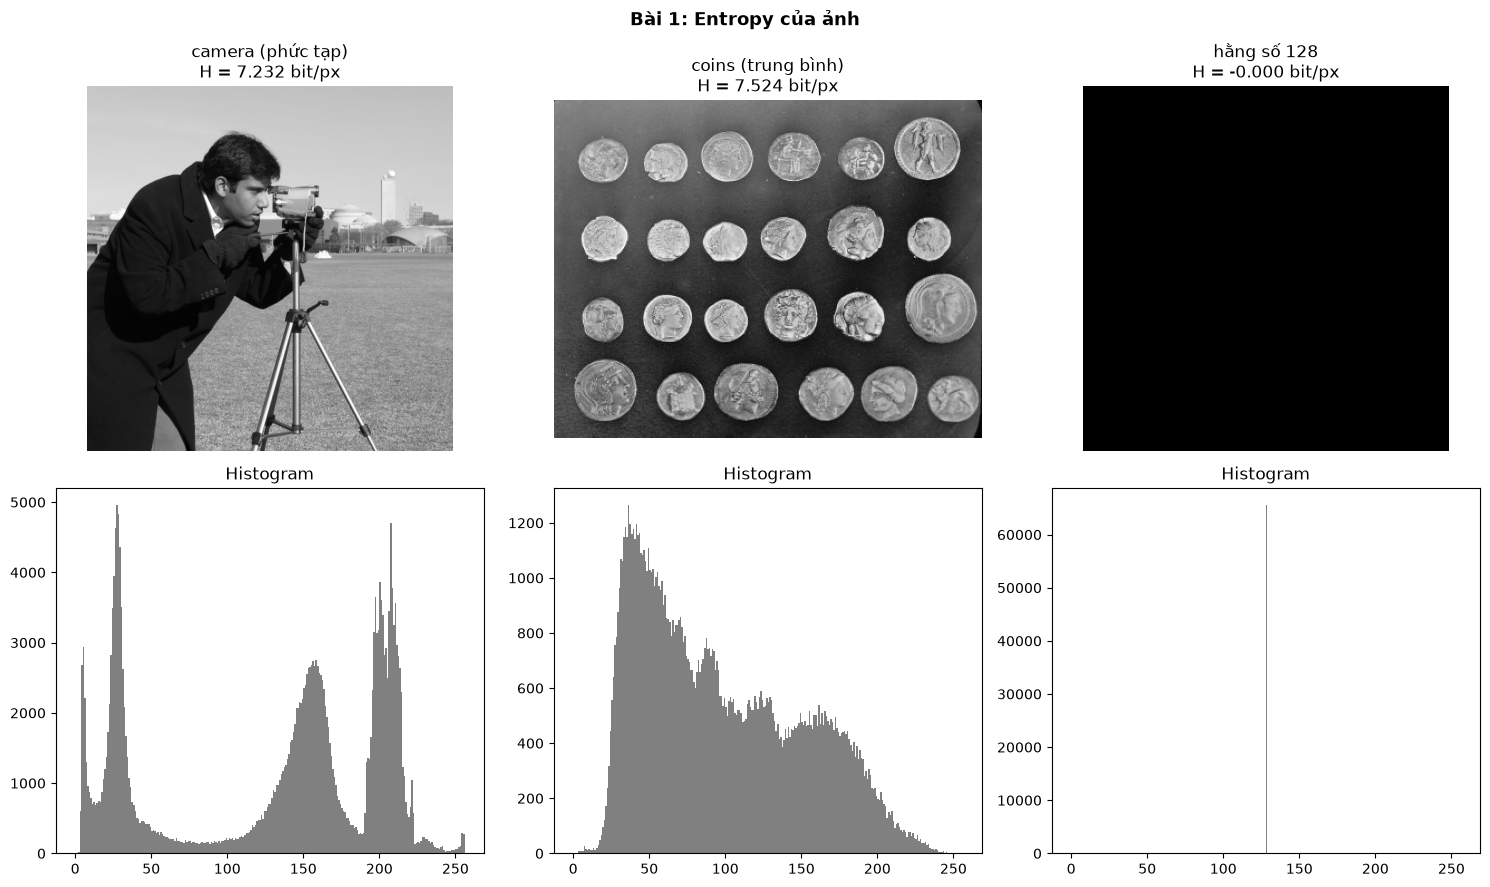

In [2]:
def calculate_entropy(img):
    """Tính entropy (bit/pixel) của ảnh xám."""
    hist, _ = np.histogram(img.flatten(), 256, [0, 256])
    p = hist / img.size
    p = p[p > 0]                        # bỏ các p = 0 để tránh log(0)
    return -np.sum(p * np.log2(p))

# 1. Chuẩn bị 3 ảnh
img_cam   = data.camera()
img_coin  = data.coins()
img_flat  = (np.ones((256, 256)) * 128).astype(np.uint8)  # ảnh hằng số

# 2. Tính entropy
imgs   = [img_cam, img_coin, img_flat]
names  = ['camera (phức tạp)', 'coins (trung bình)', 'hằng số 128']
ents   = [calculate_entropy(im) for im in imgs]

print(f"{'Ảnh':<25}{'Entropy (bit/pixel)':>22}")
print("-" * 47)
for n, e in zip(names, ents):
    print(f"{n:<25}{e:>22.4f}")

# 3. Hiển thị ảnh + histogram
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (im, name) in enumerate(zip(imgs, names)):
    axes[0, i].imshow(im, cmap='gray')
    axes[0, i].set_title(f'{name}\nH = {ents[i]:.3f} bit/px')
    axes[0, i].axis('off')
    axes[1, i].hist(im.ravel(), 256, [0, 256], color='gray')
    axes[1, i].set_title('Histogram')

plt.suptitle('Bài 1: Entropy của ảnh', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/bai1_entropy.png', dpi=100, bbox_inches='tight')
plt.show()

# NHẬN XÉT:
# - Ảnh hằng số: entropy = 0 (chỉ 1 mức xám duy nhất, không có bất định).
# - Ảnh camera/coins: entropy cao (6-8 bit) do phân bố mức xám đa dạng.
# - Định lý Shannon: entropy là giới hạn dưới của số bit trung bình/pixel.

**📸 Kết quả:** Bảng entropy cho thấy ảnh hằng số có H=0, ảnh phức tạp có H cao (6–8 bit/px).

---

## Bài 2: Tỷ lệ nén (Compression Ratio) và Dư thừa (Redundancy)

**Mức độ:** Cơ bản

**Mục tiêu:** Áp dụng công thức `C = b / b'` và `R = 1 - 1/C`.

**Yêu cầu:**
1. Cho ảnh xám 8-bit kích thước `M×N`, tính số bit gốc `b = M·N·8`.
2. Giả sử dùng một số phương pháp nén cho ra số bit `b'` như sau (đơn vị: bit):
   - Nén 2:1
   - Nén 5:1
   - Nén 10:1
   - Nén 20:1
3. Tính và in bảng: `b'`, `C`, `R` cho từng phương pháp.
4. Vẽ biểu đồ cột so sánh `R` giữa các phương pháp; lưu vào `output/bai2_ratio.png`.

**Lời giải:**

Số bit gốc b = 2,097,152 bit = 256.0 KB

  C (giả định)  b_prime (bit)    C tính lại     R = 1 - 1/C
-----------------------------------------------------------
             2      1,048,576          2.00          0.5000
             5        419,430          5.00          0.8000
            10        209,715         10.00          0.9000
            20        104,857         20.00          0.9500


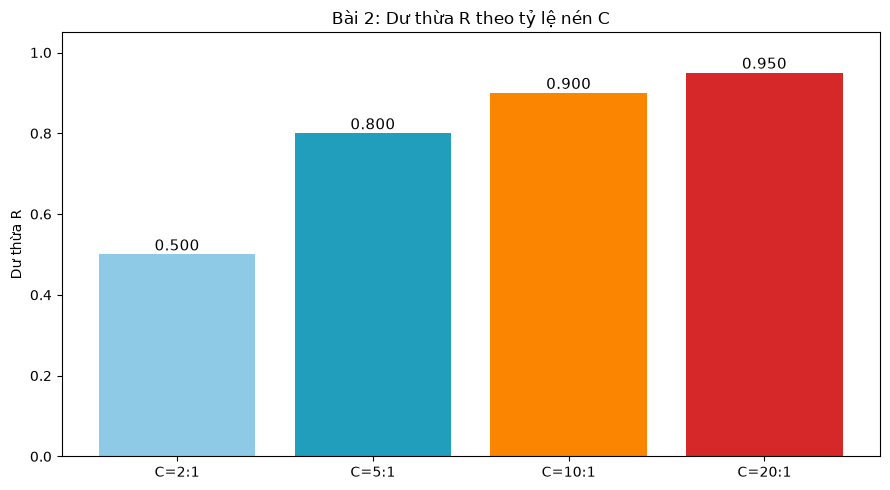

In [4]:
# 1. Ảnh giả định: camera 512×512, 8-bit
M, N = 512, 512
b = M * N * 8
print(f"Số bit gốc b = {b:,} bit = {b/8/1024:.1f} KB\n")

# 2. Các tỷ lệ nén giả định
C_list = [2, 5, 10, 20]

# 3. In bảng
print(f"{'C (giả định)':>14}{'b_prime (bit)':>15}{'C tính lại':>14}{'R = 1 - 1/C':>16}")
print("-" * 59)
for C in C_list:
    b_prime = b // C
    C_calc  = b / b_prime
    R       = 1 - 1 / C_calc
    print(f"{C:>14}{b_prime:>15,}{C_calc:>14.2f}{R:>16.4f}")

# 4. Biểu đồ cột
fig, ax = plt.subplots(figsize=(9, 5))
R_vals = [1 - 1/C for C in C_list]
bars = ax.bar([f'C={c}:1' for c in C_list], R_vals,
              color=['#8ecae6', '#219ebc', '#fb8500', '#d62828'])
for bar, r in zip(bars, R_vals):
    ax.text(bar.get_x() + bar.get_width()/2, r + 0.01,
            f'{r:.3f}', ha='center', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Dư thừa R')
ax.set_title('Bài 2: Dư thừa R theo tỷ lệ nén C')
plt.tight_layout()
plt.savefig('output/bai2_ratio.png', dpi=100, bbox_inches='tight')
plt.show()

**📸 Kết quả:** Bảng số liệu + biểu đồ cột. Càng nén mạnh (C lớn) thì tỷ lệ dữ liệu bị loại bỏ R càng cao.

---

## Bài 3: Đo lường chất lượng — RMSE & SNR

**Mức độ:** Cơ bản

**Mục tiêu:** Cài đặt RMSE và SNR để đánh giá khách quan chất lượng ảnh sau nén.

**Yêu cầu:**
1. Cài đặt `calculate_rmse(orig, comp)` và `calculate_snr(orig, comp)`.
2. Tải ảnh `data.camera()`. Tạo 3 phiên bản "nén giả" bằng cách lượng tử hóa mức xám xuống 7-bit, 5-bit, 3-bit.
3. Tính RMSE và SNR của mỗi phiên bản so với ảnh gốc → in bảng.
4. Hiển thị 4 ảnh (gốc + 3 phiên bản) kèm RMSE/SNR tương ứng.
5. Lưu kết quả vào `output/bai3_quality.png`.

**Lời giải:**

Phiên bản              RMSE      SNR (dB)
-----------------------------------------
Ảnh gốc              0.0000             ∞
7-bit                0.7048         46.48
5-bit                4.2263         30.92
3-bit               18.3268         18.18


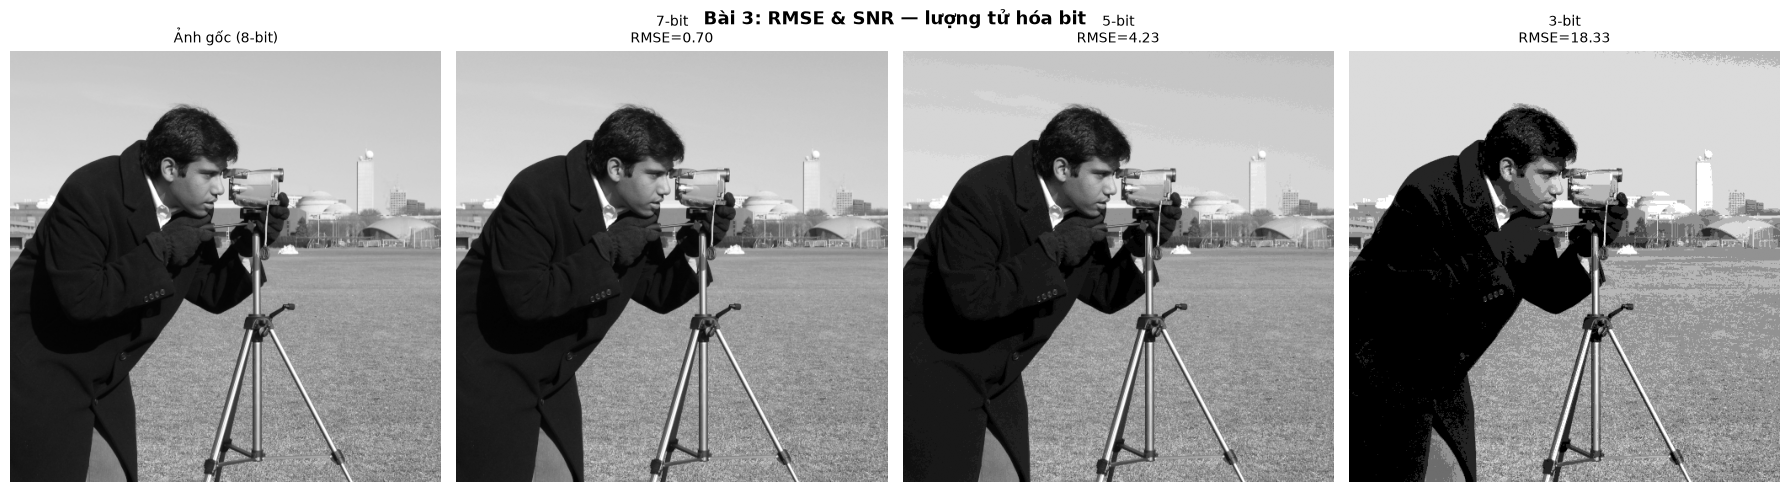

In [5]:
def calculate_rmse(orig, comp):
    return np.sqrt(np.mean((orig.astype(np.float32) - comp.astype(np.float32)) ** 2))

def calculate_snr(orig, comp):
    signal_power = np.mean(orig.astype(np.float32) ** 2)
    noise_power  = np.mean((orig.astype(np.float32) - comp.astype(np.float32)) ** 2)
    if noise_power == 0:
        return float('inf')
    return 10 * np.log10(signal_power / noise_power)

img = data.camera()

def quantize_bits(img, bits):
    step = 256 // (2 ** bits)
    return ((img // step) * step).astype(np.uint8)

bits_list  = [7, 5, 3]
versions   = [quantize_bits(img, b) for b in bits_list]

print(f"{'Phiên bản':<15}{'RMSE':>12}{'SNR (dB)':>14}")
print("-" * 41)
print(f"{'Ảnh gốc':<15}{0:>12.4f}{'∞':>14}")
for b, v in zip(bits_list, versions):
    print(f"{b}-bit{'':<10}{calculate_rmse(img, v):>12.4f}"
          f"{calculate_snr(img, v):>14.2f}")

show_grid(
    [img] + versions,
    ['Ảnh gốc (8-bit)'] + [f'{b}-bit\nRMSE={calculate_rmse(img, v):.2f}'
                            for b, v in zip(bits_list, versions)],
    ncols=4, figsize=(18, 5),
    save_path='output/bai3_quality.png',
    main_title='Bài 3: RMSE & SNR — lượng tử hóa bit'
)

**📸 Kết quả:** Càng giảm bit → RMSE tăng, SNR giảm → chất lượng giảm.

---

## Bài 4: Mã Huffman — Xây dựng cây và mã hóa

**Mức độ:** Trung bình

**Mục tiêu:** Cài đặt thuật toán Huffman từ đầu và minh họa trên chuỗi.

**Yêu cầu:**
1. Cài đặt class `Node` và các hàm `build_huffman_tree`, `generate_codes`.
2. Áp dụng cho chuỗi `"aabbc"` và chuỗi `"Cộng hoà xã hội chủ nghĩa"`.
3. In bảng mã Huffman cho từng ký tự.
4. Tính số bit trung bình/ký tự và entropy của nguồn → so sánh.
5. Trực quan hóa tần suất ký tự bằng biểu đồ cột; lưu vào `output/bai4_huffman.png`.

**Lời giải:**


=== Chuỗi: 'aabbc' (độ dài 5) ===
   Ký tự    Tần suất        Mã    Số bit
----------------------------------------
     'a'           2         0         1
     'c'           1        10         2
     'b'           2        11         2

Số bit trung bình/ký tự (Huffman): 1.6000 bit
Entropy của nguồn              : 1.5219 bit
Hiệu suất                      : 95.12%

=== Chuỗi: 'Cộng hoà xã hội chủ nghĩa' (độ dài 25) ===
   Ký tự    Tần suất        Mã    Số bit
----------------------------------------
     ' '           5        01         2
     'ộ'           2       000         3
     'h'           4       100         3
     'i'           1      0010         4
     'ã'           1      0011         4
     'g'           2      1011         4
     'n'           2      1110         4
     'ủ'           1     10100         5
     'c'           1     10101         5
     'a'           1     11000         5
     'o'           1     11001         5
     'x'           1     11010         5

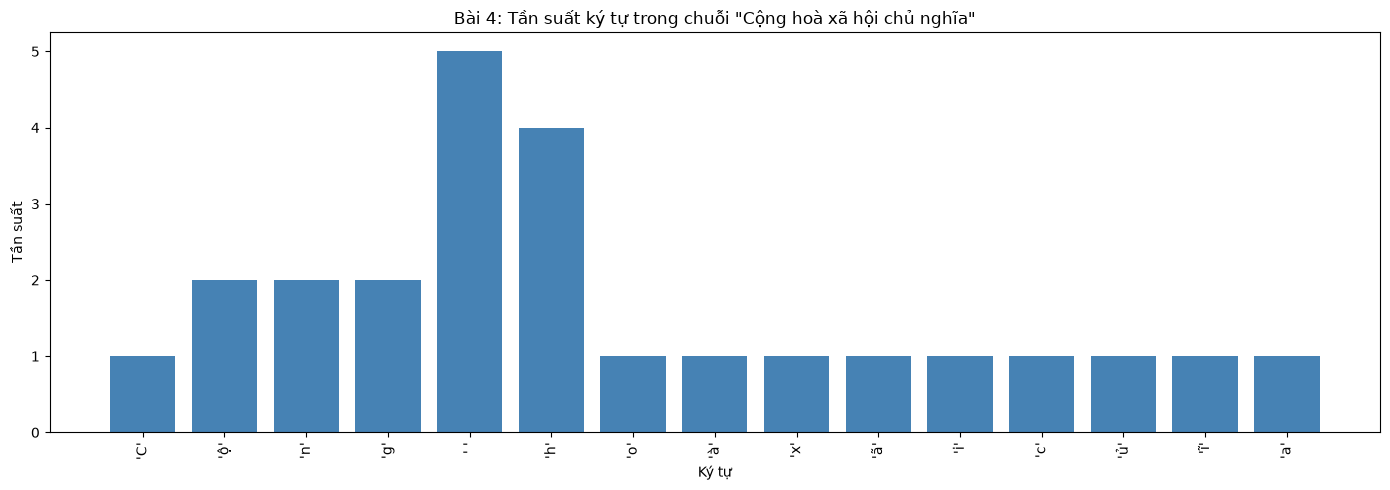

In [6]:
class Node:
    def __init__(self, char, freq):
        self.char  = char
        self.freq  = freq
        self.left  = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq


def build_huffman_tree(text):
    freq = Counter(text)
    heap = [Node(c, f) for c, f in freq.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        left  = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = Node(None, left.freq + right.freq)
        merged.left, merged.right = left, right
        heapq.heappush(heap, merged)
    return heap[0]


def generate_codes(node, prefix="", code_map=None):
    if code_map is None:
        code_map = {}
    if node is not None:
        if node.char is not None:
            code_map[node.char] = prefix
        generate_codes(node.left,  prefix + "0", code_map)
        generate_codes(node.right, prefix + "1", code_map)
    return code_map


# --- Áp dụng ---
texts = ["aabbc", "Cộng hoà xã hội chủ nghĩa"]

for text in texts:
    print(f"\n=== Chuỗi: '{text}' (độ dài {len(text)}) ===")
    tree  = build_huffman_tree(text)
    codes = generate_codes(tree)

    # In bảng mã
    print(f"{'Ký tự':>8}{'Tần suất':>12}{'Mã':>10}{'Số bit':>10}")
    print("-" * 40)
    for ch, code in sorted(codes.items(), key=lambda x: len(x[1])):
        ch_disp = repr(ch)
        print(f"{ch_disp:>8}{text.count(ch):>12}{code:>10}{len(code):>10}")

    # Tính bit trung bình và entropy
    total_chars = len(text)
    avg_bits = sum(text.count(c) * len(codes[c]) for c in codes) / total_chars
    probs    = np.array([text.count(c) / total_chars for c in codes])
    entropy  = -np.sum(probs * np.log2(probs))

    print(f"\nSố bit trung bình/ký tự (Huffman): {avg_bits:.4f} bit")
    print(f"Entropy của nguồn              : {entropy:.4f} bit")
    print(f"Hiệu suất                      : {entropy/avg_bits*100:.2f}%")

# --- Biểu đồ tần suất ký tự của câu ---
text2 = texts[1]
freq  = Counter(text2)
chars = list(freq.keys())
counts = list(freq.values())

plt.figure(figsize=(14, 5))
plt.bar(range(len(chars)), counts, color='steelblue')
plt.xticks(range(len(chars)), [repr(c) for c in chars], rotation=90)
plt.title(f'Bài 4: Tần suất ký tự trong chuỗi "{text2}"')
plt.xlabel('Ký tự'); plt.ylabel('Tần suất')
plt.tight_layout()
plt.savefig('output/bai4_huffman.png', dpi=100, bbox_inches='tight')
plt.show()

**📸 Kết quả:** Bảng mã Huffman cho từng ký tự; cột tần suất cho thấy ký tự xuất hiện nhiều (dấu cách, 'a', 'o') có mã ngắn.

---

## Bài 5: Mã hóa và giải mã Golomb-Rice

**Mức độ:** Trung bình

**Mục tiêu:** Cài đặt Golomb-Rice code với tham số `k`.

**Yêu cầu:**
1. Cài đặt `golomb_rice_encode(n, k)` và `golomb_rice_decode(bits, k)`.
2. Mã hóa và giải mã các số nguyên: `n ∈ {0, 1, 2, 3, 5, 13, 27, 100}` với `k=2`.
3. In bảng: `n | q | r | mã | giải mã`.
4. In bảng so sánh số bit với mã nhị phân cố định 8-bit.
5. Lưu kết quả bảng vào file `output/bai5_golomb.txt`.

**Lời giải:**

In [7]:
def golomb_rice_encode(n, k):
    M = 2 ** k
    q = n // M
    r = n % M
    quotient_bits  = '0' * q + '1'
    remainder_bits = f"{r:0{k}b}"
    return quotient_bits + remainder_bits


def golomb_rice_decode(bits, k):
    q = 0
    for bit in bits:
        if bit == '0':
            q += 1
        else:
            break
    r_bits = bits[q+1 : q+1+k]
    r = int(r_bits, 2)
    return q * (2 ** k) + r


n_list = [0, 1, 2, 3, 5, 13, 27, 100]
k = 2

lines = []
lines.append(f"{'n':>5}{'q':>5}{'r':>5}{'Mã Golomb-Rice':>25}{'Số bit':>10}{'Giải mã':>10}")
lines.append("-" * 60)

total_gr = 0
total_fixed = 0
for n in n_list:
    code = golomb_rice_encode(n, k)
    decoded = golomb_rice_decode(code, k)
    q = n // (2 ** k)
    r = n %  (2 ** k)
    lines.append(f"{n:>5}{q:>5}{r:>5}{code:>25}{len(code):>10}{decoded:>10}")
    total_gr    += len(code)
    total_fixed += 8

lines.append("-" * 60)
lines.append(f"Tổng bit Golomb-Rice  : {total_gr} bit")
lines.append(f"Tổng bit cố định 8-bit: {total_fixed} bit")
lines.append(f"Tiết kiệm             : {(1-total_gr/total_fixed)*100:.1f}%")

print("\n".join(lines))

with open('output/bai5_golomb.txt', 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))

    n    q    r           Mã Golomb-Rice    Số bit   Giải mã
------------------------------------------------------------
    0    0    0                      100         3         0
    1    0    1                      101         3         1
    2    0    2                      110         3         2
    3    0    3                      111         3         3
    5    1    1                     0101         4         5
   13    3    1                   000101         6        13
   27    6    3                000000111         9        27
  100   25    00000000000000000000000000100        28       100
------------------------------------------------------------
Tổng bit Golomb-Rice  : 59 bit
Tổng bit cố định 8-bit: 64 bit
Tiết kiệm             : 7.8%


**📸 Kết quả:** Bảng chi tiết cho thấy Golomb-Rice hiệu quả khi các số nhỏ chiếm đa số.

---

## Bài 6: Mã hóa số học (Arithmetic Coding)

**Mức độ:** Trung bình

**Mục tiêu:** Cài đặt thuật toán mã hóa số học cho chuỗi ký tự.

**Yêu cầu:**
1. Cài đặt `arithmetic_encode(message, probs)` và `arithmetic_decode(value, probs, n_chars)`.
2. Áp dụng với bảng xác suất `{A:0.5, B:0.3, C:0.2}` cho các chuỗi: `"A"`, `"AB"`, `"BAC"`, `"ABC"`.
3. In bảng: chuỗi | giá trị mã hóa | chuỗi giải mã.
4. Kiểm tra round-trip: mã hóa → giải mã → so sánh với chuỗi gốc.
5. Lưu kết quả vào `output/bai6_arithmetic.txt`.

**Lời giải:**

In [8]:
def arithmetic_encode(message, probs):
    low, high = 0.0, 1.0
    for char in message:
        range_size = high - low
        cum_prob = 0.0
        for c, p in probs.items():
            if c == char:
                high = low + range_size * (cum_prob + p)
                low  = low + range_size * cum_prob
                break
            cum_prob += p
    return (low + high) / 2


def arithmetic_decode(value, probs, n_chars):
    low, high = 0.0, 1.0
    decoded = ""
    for _ in range(n_chars):
        range_size = high - low
        # Xác định ký tự chứa value trong khoảng [low, high)
        cum_prob = 0.0
        for c, p in probs.items():
            sub_low  = low + range_size * cum_prob
            sub_high = sub_low + range_size * p
            if sub_low <= value < sub_high:
                decoded += c
                low, high = sub_low, sub_high
                break
            cum_prob += p
    return decoded


probs = {'A': 0.5, 'B': 0.3, 'C': 0.2}
messages = ["A", "AB", "BAC", "ABC"]

lines = []
lines.append(f"{'Chuỗi gốc':>12}{'Giá trị mã hóa':>20}{'Chuỗi giải mã':>18}{'Khớp?':>10}")
lines.append("-" * 60)
for msg in messages:
    val      = arithmetic_encode(msg, probs)
    decoded  = arithmetic_decode(val, probs, len(msg))
    lines.append(f"{msg:>12}{val:>20.6f}{decoded:>18}{str(msg == decoded):>10}")

print("\n".join(lines))
with open('output/bai6_arithmetic.txt', 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))

   Chuỗi gốc      Giá trị mã hóa     Chuỗi giải mã     Khớp?
------------------------------------------------------------
           A            0.250000                 A      True
          AB            0.325000                AB      True
         BAC            0.635000               BAC      True
         ABC            0.385000               ABC      True


**📸 Kết quả:** Bảng cho thấy round-trip thành công — chuỗi giải mã luôn khớp chuỗi gốc.

---

## Bài 7: Nén và giải nén LZW

**Mức độ:** Trung bình

**Mục tiêu:** Cài đặt LZW cho chuỗi, đảm bảo round-trip.

**Yêu cầu:**
1. Cài đặt `lzw_compress(text)` và `lzw_decompress(codes)`.
2. Áp dụng cho chuỗi `"ABAAABABA"` và một chuỗi dài hơn `"TOBEORNOTTOBEORTOBEORNOT"`.
3. In bảng quá trình mã hóa cho chuỗi `"ABAAABABA"` (từng bước).
4. Kiểm tra round-trip: giải nén → so sánh với chuỗi gốc.
5. Lưu kết quả vào `output/bai7_lzw.txt`.

**Lời giải:**

In [9]:
def lzw_compress(text):
    dict_size = 256
    dictionary = {chr(i): i for i in range(dict_size)}
    w = ""
    compressed = []
    steps = []   # lưu vết
    for c in text:
        wc = w + c
        if wc in dictionary:
            w = wc
        else:
            compressed.append(dictionary[w])
            steps.append((w, c, dictionary[w], dict_size))
            dictionary[wc] = dict_size
            dict_size += 1
            w = c
    if w:
        compressed.append(dictionary[w])
        steps.append((w, '', dictionary[w], None))
    return compressed, steps


def lzw_decompress(codes):
    dict_size = 256
    dictionary = {i: chr(i) for i in range(dict_size)}
    result = []
    w = chr(codes[0])
    result.append(w)
    for k in codes[1:]:
        if k in dictionary:
            entry = dictionary[k]
        elif k == dict_size:
            entry = w + w[0]
        else:
            raise ValueError("Mã LZW không hợp lệ")
        result.append(entry)
        dictionary[dict_size] = w + entry[0]
        dict_size += 1
        w = entry
    return "".join(result)


texts = ["ABAAABABA", "TOBEORNOTTOBEORTOBEORNOT"]
lines = []
for text in texts:
    codes, steps = lzw_compress(text)
    decoded = lzw_decompress(codes)
    lines.append(f"\n=== Chuỗi: {text} ===")
    lines.append(f"Chuỗi gốc     : {text}")
    lines.append(f"Mã LZW        : {codes}")
    lines.append(f"Giải nén      : {decoded}")
    lines.append(f"Round-trip OK : {text == decoded}")
    lines.append(f"Độ dài gốc    : {len(text)} ký tự")
    lines.append(f"Độ dài nén    : {len(codes)} mã")

    if text == "ABAAABABA":
        lines.append("\nQuá trình mã hóa:")
        lines.append(f"{'Bước':>5}{'w':>6}{'c':>5}{'Xuất mã':>10}{'Mã mới':>10}")
        lines.append("-" * 40)
        for i, (w, c, out, new) in enumerate(steps, 1):
            new_str = f"{new}->{w+c}" if new else "-"
            lines.append(f"{i:>5}{w:>6}{c:>5}{out:>10}{new_str:>10}")

print("\n".join(lines))
with open('output/bai7_lzw.txt', 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))


=== Chuỗi: ABAAABABA ===
Chuỗi gốc     : ABAAABABA
Mã LZW        : [65, 66, 65, 258, 257, 257]
Giải nén      : ABAAABABA
Round-trip OK : True
Độ dài gốc    : 9 ký tự
Độ dài nén    : 6 mã

Quá trình mã hóa:
 Bước     w    c   Xuất mã    Mã mới
----------------------------------------
    1     A    B        65   256->AB
    2     B    A        66   257->BA
    3     A    A        65   258->AA
    4    AA    B       258  259->AAB
    5    BA    B       257  260->BAB
    6    BA            257         -

=== Chuỗi: TOBEORNOTTOBEORTOBEORNOT ===
Chuỗi gốc     : TOBEORNOTTOBEORTOBEORNOT
Mã LZW        : [84, 79, 66, 69, 79, 82, 78, 79, 84, 256, 258, 260, 265, 259, 261, 263]
Giải nén      : TOBEORNOTTOBEORTOBEORNOT
Round-trip OK : True
Độ dài gốc    : 24 ký tự
Độ dài nén    : 16 mã


**📸 Kết quả:** Bảng bước mã hóa + round-trip thành công. Chuỗi có nhiều mẫu lặp lại → nén hiệu quả.

---

## Bài 8: Mã hóa Run-Length (RLE) cho ảnh nhị phân

**Mức độ:** Trung bình

**Mục tiêu:** Cài đặt RLE và áp dụng cho ảnh nhị phân.

**Yêu cầu:**
1. Cài đặt `rle_encode(arr)` và `rle_decode(pairs, shape)` cho mảng 1D.
2. Tạo ảnh nhị phân từ `data.camera()` (ngưỡng > 128) rồi "flatten".
3. Áp dụng RLE và tính tỷ lệ nén (so với mảng gốc 0/1).
4. Giải nén và kiểm tra round-trip.
5. Hiển thị ảnh gốc và ảnh sau khi giải nén; lưu vào `output/bai8_rle.png`.

**Lời giải:**

Kích thước gốc : 262,144 pixel (262,144 bit)
Số cặp RLE     : 11,749 cặp (105,741 bit)
Tỷ lệ nén C    : 2.48:1
Dư thừa R      : 0.5966
Round-trip OK  : True


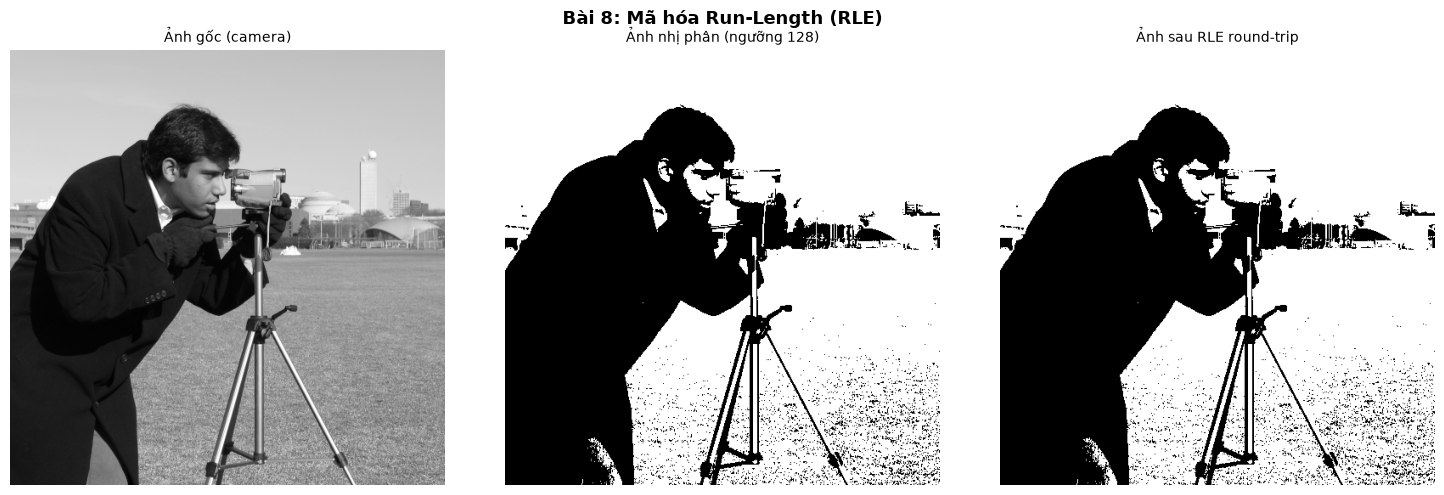

In [10]:
def rle_encode(arr):
    """Mã hóa mảng 1D thành danh sách (giá trị, độ dài)."""
    if len(arr) == 0:
        return []
    pairs = []
    cur_val = arr[0]
    count = 1
    for v in arr[1:]:
        if v == cur_val:
            count += 1
        else:
            pairs.append((cur_val, count))
            cur_val = v
            count = 1
    pairs.append((cur_val, count))
    return pairs


def rle_decode(pairs, shape):
    """Giải mã danh sách (giá trị, độ dài) thành mảng có kích thước shape."""
    flat = []
    for val, cnt in pairs:
        flat.extend([val] * cnt)
    return np.array(flat, dtype=np.uint8).reshape(shape)


# 1. Tạo ảnh nhị phân
img = data.camera()
binary = (img > 128).astype(np.uint8)

# 2. RLE
flat = binary.flatten()
pairs = rle_encode(flat)

# 3. Tỷ lệ nén (ước lượng)
bits_orig = len(flat) * 1                 # mỗi pixel nhị phân 1 bit
bits_rle  = len(pairs) * (1 + 8)          # giả định: 1 bit cho giá trị + 8 bit cho độ dài
C = bits_orig / bits_rle
print(f"Kích thước gốc : {len(flat):,} pixel ({bits_orig:,} bit)")
print(f"Số cặp RLE     : {len(pairs):,} cặp ({bits_rle:,} bit)")
print(f"Tỷ lệ nén C    : {C:.2f}:1")
print(f"Dư thừa R      : {1 - 1/C:.4f}")

# 4. Round-trip
decoded = rle_decode(pairs, binary.shape)
print(f"Round-trip OK  : {np.array_equal(binary, decoded)}")

# 5. Hiển thị
show_grid(
    [img, binary * 255, decoded * 255],
    ['Ảnh gốc (camera)',
     'Ảnh nhị phân (ngưỡng 128)',
     'Ảnh sau RLE round-trip'],
    ncols=3, figsize=(15, 5),
    save_path='output/bai8_rle.png',
    main_title='Bài 8: Mã hóa Run-Length (RLE)'
)

**📸 Kết quả:** Ảnh nhị phân sau RLE round-trip giống hệt ảnh gốc; tỷ lệ nén thể hiện mức độ hiệu quả của RLE.

---

## Bài 9: Mã hóa Bit-Plane và nén

**Mức độ:** Trung bình

**Mục tiêu:** Phân tích mức độ đóng góp của từng bit-plane và thử nén bằng RLE.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Tách 8 bit-plane.
3. Áp dụng RLE cho từng bit-plane và tính tỷ lệ nén tương ứng.
4. In bảng tỷ lệ nén 8 bit-plane.
5. Hiển thị 8 bit-plane (bit 7 → bit 0); lưu vào `output/bai9_bitplane.png`.

**Lời giải:**

 Bit-plane    Số pixel    Số cặp RLE   Tỷ lệ nén
--------------------------------------------------
         0     262,144       124,196        0.23
         1     262,144       108,383        0.27
         2     262,144        90,954        0.32
         3     262,144        73,302        0.40
         4     262,144        58,738        0.50
         5     262,144        44,345        0.66
         6     262,144        16,798        1.73
         7     262,144        11,129        2.62


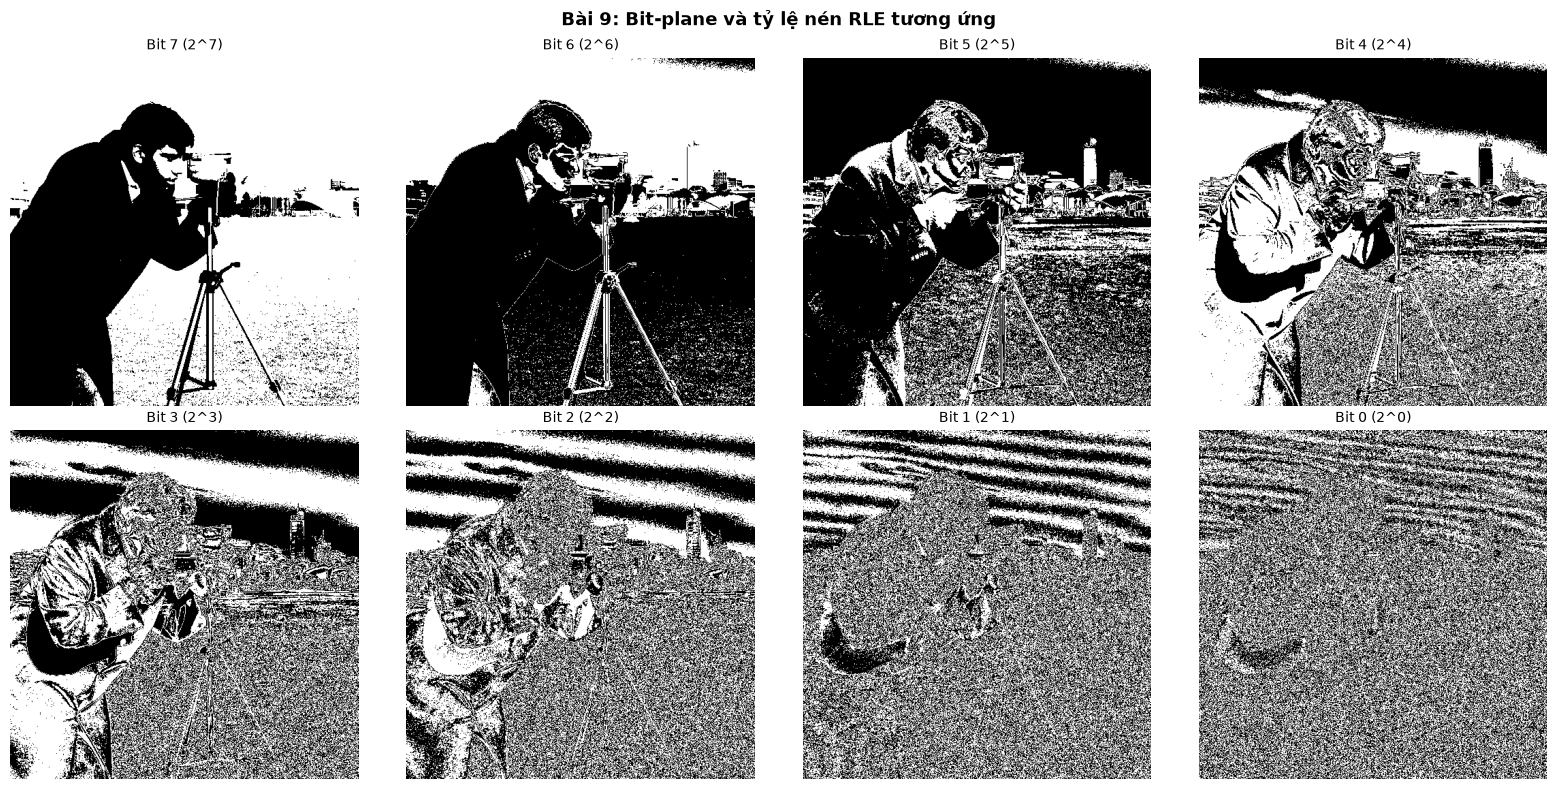

In [11]:
img = data.camera()

planes = [((img >> b) & 1).astype(np.uint8) for b in range(8)]

# Áp dụng RLE cho từng bit-plane
print(f"{'Bit-plane':>10}{'Số pixel':>12}{'Số cặp RLE':>14}{'Tỷ lệ nén':>12}")
print("-" * 50)
ratio_list = []
for b, plane in enumerate(planes):
    pairs = rle_encode(plane.flatten())
    bits_orig = plane.size * 1
    bits_rle  = len(pairs) * 9
    C = bits_orig / bits_rle
    ratio_list.append(C)
    print(f"{b:>10}{plane.size:>12,}{len(pairs):>14,}{C:>12.2f}")

# Trực quan hóa
show_grid(
    [p * 255 for p in planes[::-1]],     # hiển thị từ MSB → LSB
    [f'Bit {b} (2^{b})' for b in range(7, -1, -1)],
    ncols=4, figsize=(16, 8),
    save_path='output/bai9_bitplane.png',
    main_title='Bài 9: Bit-plane và tỷ lệ nén RLE tương ứng'
)

# NHẬN XÉT:
# - Bit 7 (MSB) ít "lộn xộn" → RLE nén tốt hơn.
# - Bit 0 (LSB) gần như ngẫu nhiên → RLE nén kém, thường không nên nén bit-plane này.

**📸 Kết quả:** Bit-plane cao có cấu trúc rõ (nén tốt), bit-plane thấp gần như nhiễu (nén kém).

---

## Bài 10: Block Transform Coding — DCT cho khối 8×8

**Mức độ:** Nâng cao

**Mục tiêu:** Áp dụng DCT, quantization và IDCT cho một khối 8×8.

**Yêu cầu:**
1. Tải ảnh `data.camera()`, cắt một khối 8×8 từ vùng giữa.
2. Áp dụng DCT bằng `cv2.dct` (cần mở rộng ảnh lên `float32`).
3. Lượng tử hóa với Q-table mẫu (JPEG-like).
4. Giải lượng tử hóa và IDCT để tái tạo khối.
5. Hiển thị: khối gốc, hệ số DCT (log-scale), Q-table, khối sau lượng tử hóa, khối tái tạo.
6. Lưu kết quả vào `output/bai10_dct_block.png`.

**Lời giải:**

RMSE giữa khối gốc và khối tái tạo: 2.6366
Số hệ số khác 0 sau lượng tử hóa  : 3/64


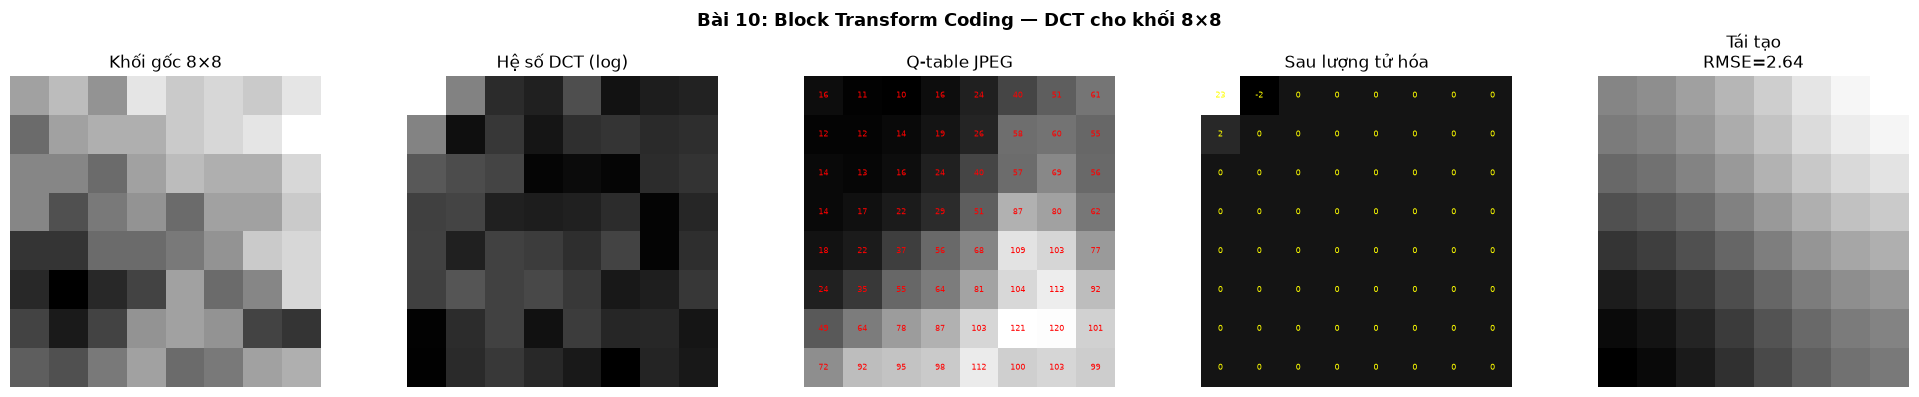

In [12]:
img = data.camera()

# Lấy khối 8×8 từ vùng giữa
r, c = 200, 200
block = img[r:r+8, c:c+8].astype(np.float32)

# 1. DCT
dct_block = cv2.dct(block)

# 2. Q-table JPEG chuẩn (cho chất lượng trung bình)
Q = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)

# 3. Lượng tử hóa
quantized = np.round(dct_block / Q)

# 4. Giải lượng tử + IDCT
dequantized = quantized * Q
reconstructed = cv2.idct(dequantized).astype(np.float32)

# Đo lường
rmse = calculate_rmse(block, reconstructed)
print(f"RMSE giữa khối gốc và khối tái tạo: {rmse:.4f}")
print(f"Số hệ số khác 0 sau lượng tử hóa  : {np.count_nonzero(quantized)}/64")

# 5. Hiển thị
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(block, cmap='gray'); axes[0].set_title('Khối gốc 8×8'); axes[0].axis('off')

dct_vis = 20 * np.log(1 + np.abs(dct_block))
axes[1].imshow(dct_vis, cmap='gray'); axes[1].set_title('Hệ số DCT (log)'); axes[1].axis('off')

axes[2].imshow(Q, cmap='gray'); axes[2].set_title('Q-table JPEG'); axes[2].axis('off')
for i in range(8):
    for j in range(8):
        axes[2].text(j, i, int(Q[i,j]), ha='center', va='center', fontsize=6, color='red')

axes[3].imshow(quantized, cmap='gray'); axes[3].set_title('Sau lượng tử hóa'); axes[3].axis('off')
for i in range(8):
    for j in range(8):
        axes[3].text(j, i, int(quantized[i,j]), ha='center', va='center', fontsize=6, color='yellow')

axes[4].imshow(reconstructed, cmap='gray'); axes[4].set_title(f'Tái tạo\nRMSE={rmse:.2f}'); axes[4].axis('off')

plt.suptitle('Bài 10: Block Transform Coding — DCT cho khối 8×8',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/bai10_dct_block.png', dpi=100, bbox_inches='tight')
plt.show()

# NHẬN XÉT:
# - Hệ số DC (góc trái trên) rất lớn → mang thông tin nền.
# - Hệ số AC tần số cao thường về 0 sau lượng tử hóa.
# - Sau khi tái tạo, khối vẫn giữ được cấu trúc chính.

**📸 Kết quả:** Khối gốc → DCT → Q-table → khối lượng tử hóa → khối tái tạo. Thấy rõ phần lớn hệ số AC bị triệt tiêu.

---

## Bài 11: Nén ảnh hoàn chỉnh với DCT + Zigzag + RLE

**Mức độ:** Nâng cao

**Mục tiêu:** Xây dựng pipeline nén ảnh JPEG đơn giản.

**Yêu cầu:**
1. Chia ảnh `data.camera()` (kích thước bội số của 8) thành các khối 8×8.
2. Áp dụng DCT + lượng tử hóa với Q-table.
3. Quét Zigzag và áp dụng RLE (chỉ mã hóa hệ số cuối cùng khác 0).
4. Đo tỷ lệ nén thực tế (theo số hệ số).
5. Giải nén ngược: RLE-decode → Zigzag-inverse → Dequantize → IDCT → ghép khối.
6. Hiển thị ảnh gốc + ảnh sau nén + so sánh RMSE/SNR.

**Lời giải:**

Số khối               : 4096
Tổng số hệ số trong block: 262144
Số hệ số thực sự lưu  : 56026
Tỷ lệ nén (hệ số)     : 4.68:1

RMSE (toàn ảnh): 5.9925
SNR  (toàn ảnh): 27.89 dB


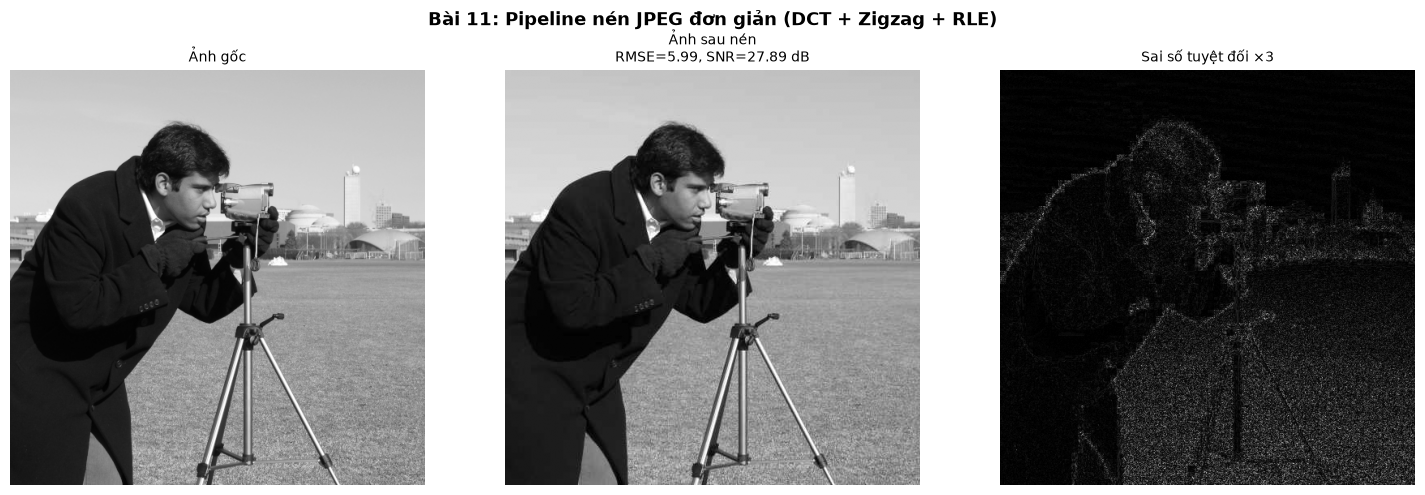

True

In [13]:
img = data.camera()
H, W = img.shape
# Cắt cho bội số của 8
H8, W8 = (H // 8) * 8, (W // 8) * 8
img = img[:H8, :W8]

Q = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)

# Chỉ số zigzag cho khối 8×8
zigzag = np.array([
    [ 0,  1,  5,  6, 14, 15, 27, 28],
    [ 2,  4,  7, 13, 16, 26, 29, 42],
    [ 3,  8, 12, 17, 25, 30, 41, 43],
    [ 9, 11, 18, 24, 31, 40, 44, 53],
    [10, 19, 23, 32, 39, 45, 52, 54],
    [20, 22, 33, 38, 46, 51, 55, 60],
    [21, 34, 37, 47, 50, 56, 59, 61],
    [35, 36, 48, 49, 57, 58, 62, 63]
])
zigzag_order = np.argsort(zigzag.ravel())
zigzag_inv   = np.argsort(zigzag_order)

# --- NÉN ---
encoded_stream = []    # lưu trữ dạng list các (số hệ số khác 0, mảng hệ số)
total_coeff     = 0
for i in range(0, H8, 8):
    for j in range(0, W8, 8):
        block = img[i:i+8, j:j+8].astype(np.float32)
        dct   = cv2.dct(block)
        q     = np.round(dct / Q)
        zz    = q.ravel()[zigzag_order]
        # Cắt bỏ các 0 ở cuối (EOB)
        nz = np.nonzero(zz)[0]
        if len(nz) == 0:
            encoded_stream.append((0, np.array([])))
        else:
            k = nz[-1] + 1
            encoded_stream.append((k, zz[:k]))
        total_coeff += 1

print(f"Số khối               : {total_coeff}")
print(f"Tổng số hệ số trong block: {total_coeff * 64}")
print(f"Số hệ số thực sự lưu  : {sum(k for k, _ in encoded_stream)}")
C = (total_coeff * 64) / sum(k for k, _ in encoded_stream)
print(f"Tỷ lệ nén (hệ số)     : {C:.2f}:1")

# --- GIẢI NÉN ---
restored = np.zeros((H8, W8), dtype=np.float32)
idx = 0
for i in range(0, H8, 8):
    for j in range(0, W8, 8):
        k, zz_partial = encoded_stream[idx]
        zz_full = np.zeros(64)
        zz_full[:k] = zz_partial
        q = zz_full[zigzag_inv].reshape(8, 8)
        deq = q * Q
        block = cv2.idct(deq)
        restored[i:i+8, j:j+8] = block
        idx += 1
restored = np.clip(restored, 0, 255).astype(np.uint8)

# --- ĐÁNH GIÁ ---
rmse = calculate_rmse(img, restored)
snr  = calculate_snr(img, restored)
print(f"\nRMSE (toàn ảnh): {rmse:.4f}")
print(f"SNR  (toàn ảnh): {snr:.2f} dB")

show_grid(
    [img, restored, np.abs(img.astype(int) - restored.astype(int))],
    ['Ảnh gốc',
     f'Ảnh sau nén\nRMSE={rmse:.2f}, SNR={snr:.2f} dB',
     'Sai số tuyệt đối ×3'],
    ncols=3, figsize=(15, 5),
    save_path='output/bai11_jpeg_pipeline.png',
    main_title='Bài 11: Pipeline nén JPEG đơn giản (DCT + Zigzag + RLE)'
)

cv2.imwrite('output/bai11_compressed.png', restored)

**📸 Kết quả:** Ảnh sau nén gần như không phân biệt được bằng mắt; sai số tập trung ở vùng chi tiết cao.

---

## Bài 12: Mã hóa dự đoán DPCM cho ảnh

**Mức độ:** Nâng cao

**Mục tiêu:** Áp dụng DPCM để nén ảnh dựa trên sai số dự đoán.

**Yêu cầu:**
1. Cài đặt `dpcm_encode_1d(signal)` và `dpcm_decode_1d(encoded)`.
2. Áp dụng cho **một hàng pixel** của ảnh `data.camera()`.
3. Vẽ biểu đồ: giá trị pixel gốc vs sai số DPCM.
4. Tính entropy của ảnh gốc và entropy của sai số DPCM → so sánh.
5. Hiển thị ảnh gốc và ảnh sau khi round-trip; lưu vào `output/bai12_dpcm.png`.

**Lời giải:**

Round-trip hàng y=256 OK: True
Giá trị sai số min/max  : -92 / 158


/tmp/ipykernel_8826/114878281.py:43: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[2].hist(row, 256, [0, 256], alpha=0.5,
/tmp/ipykernel_8826/114878281.py:45: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[2].hist(np.array(enc_row) + 128, 256, [0, 256], alpha=0.5,


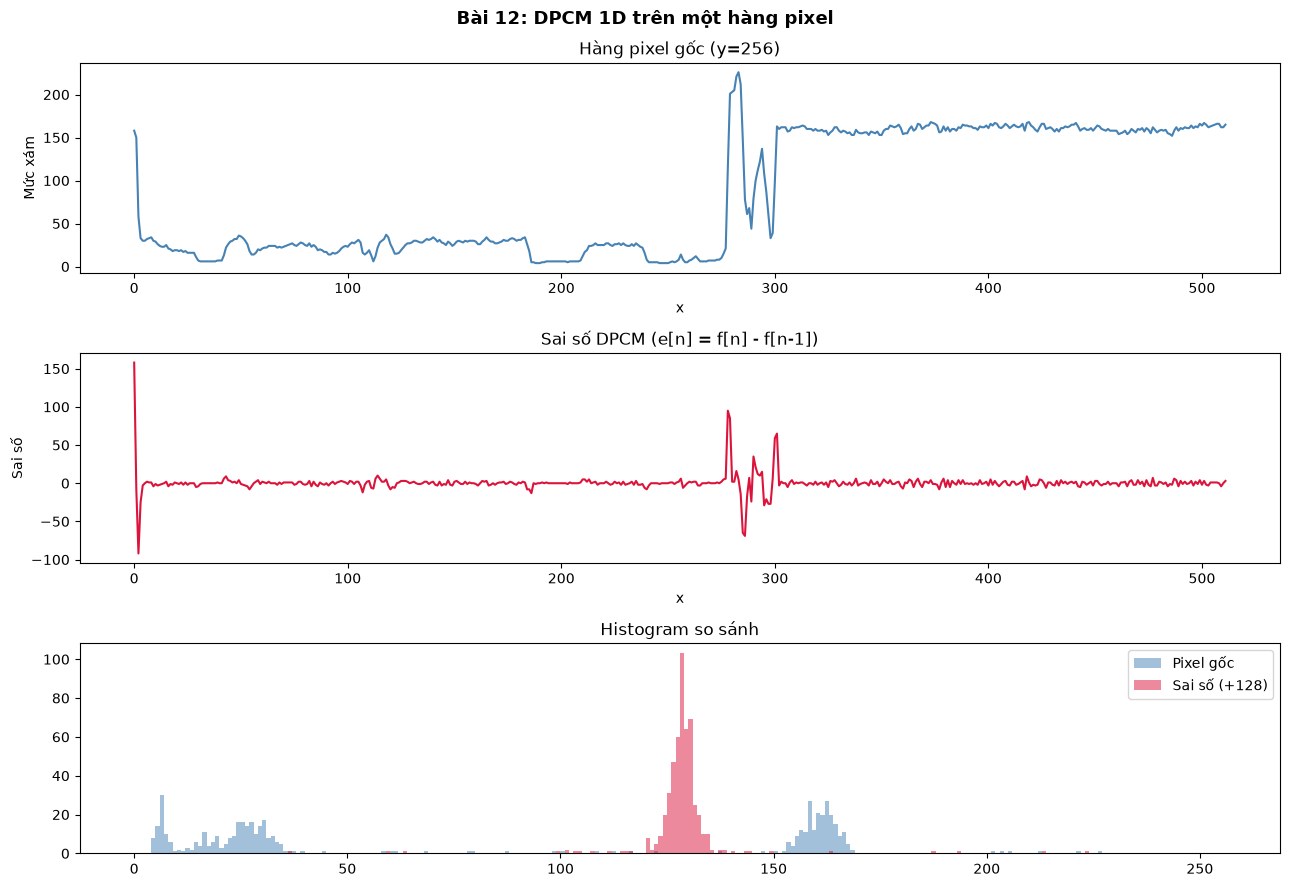


Entropy ảnh gốc     : 7.2317 bit/pixel
Entropy sai số DPCM : 3.7230 bit/pixel (hàng y=256)
→ DPCM giảm entropy 3.5087 bit/pixel → nén hiệu quả hơn


In [15]:
# ---------- Định nghĩa hàm DPCM an toàn ----------
def dpcm_encode_1d(signal):
    """signal: mảng 1D các giá trị (int/uint8). Trả về list sai số."""
    signal = signal.astype(int)                  # tránh OverflowError khi trừ
    encoded = [int(signal[0])]
    for i in range(1, len(signal)):
        predicted = int(signal[i-1])
        encoded.append(int(signal[i]) - predicted)
    return encoded


def dpcm_decode_1d(encoded):
    """Giải mã list sai số → mảng uint8."""
    decoded = [int(encoded[0])]
    for i in range(1, len(encoded)):
        predicted = int(decoded[i-1])
        decoded.append(predicted + int(encoded[i]))
    return np.array(decoded, dtype=np.uint8)


# ---------- Áp dụng ----------
img = data.camera()

# 1. Áp dụng cho 1 hàng
row = img[256, :]
enc_row = dpcm_encode_1d(row)
dec_row = dpcm_decode_1d(enc_row)

print(f"Round-trip hàng y=256 OK: {np.array_equal(row, dec_row)}")
print(f"Giá trị sai số min/max  : {min(enc_row)} / {max(enc_row)}")

# 2. So sánh giá trị gốc và sai số
fig, axes = plt.subplots(3, 1, figsize=(13, 9))

axes[0].plot(row, color='steelblue')
axes[0].set_title('Hàng pixel gốc (y=256)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Mức xám')

axes[1].plot(enc_row, color='crimson')
axes[1].set_title('Sai số DPCM (e[n] = f[n] - f[n-1])')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Sai số')

axes[2].hist(row, 256, [0, 256], alpha=0.5,
             label='Pixel gốc', color='steelblue')
axes[2].hist(np.array(enc_row) + 128, 256, [0, 256], alpha=0.5,
             label='Sai số (+128)', color='crimson')
axes[2].set_title('Histogram so sánh')
axes[2].legend()

plt.suptitle('Bài 12: DPCM 1D trên một hàng pixel',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/bai12_dpcm.png', dpi=100, bbox_inches='tight')
plt.show()

# 3. Entropy
def entropy_of_array(arr):
    """Entropy của mảng giá trị trong [-128, 127]."""
    hist, _ = np.histogram(arr, 256, [-128, 128])
    p = hist / len(arr)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

H_orig = calculate_entropy(img)
H_err  = entropy_of_array(np.array(enc_row))

print(f"\nEntropy ảnh gốc     : {H_orig:.4f} bit/pixel")
print(f"Entropy sai số DPCM : {H_err:.4f} bit/pixel (hàng y=256)")
print(f"→ DPCM giảm entropy {H_orig - H_err:.4f} bit/pixel "
      f"→ nén hiệu quả hơn")

**📸 Kết quả:**
- Sai số DPCM rất nhỏ (đa số gần 0) → entropy thấp hơn ảnh gốc.
- Đây là cơ sở của nén lossless (dự đoán + Huffman) và lossy (dự đoán + lượng tử hóa).

---

## Bài 13: Biến đổi Wavelet rời rạc (DWT)

**Mức độ:** Nâng cao

**Mục tiêu:** Hiểu biến đổi wavelet và ứng dụng trong nén ảnh.

**Yêu cầu:**
1. Cài đặt DWT 1 mức bằng bộ lọc Haar (thủ công) — hoặc dùng `pywt` nếu có.
2. Phân tích ảnh `data.camera()` thành 4 băng con: LL, LH, HL, HH.
3. Hiển thị 4 băng con; so sánh năng lượng của từng băng.
4. Thử nén lossy đơn giản: giữ lại LL + một phần các băng chi tiết, sau đó IDWT.
5. So sánh ảnh gốc với ảnh tái tạo (RMSE); lưu vào `output/bai13_wavelet.png`.

**Lời giải:**

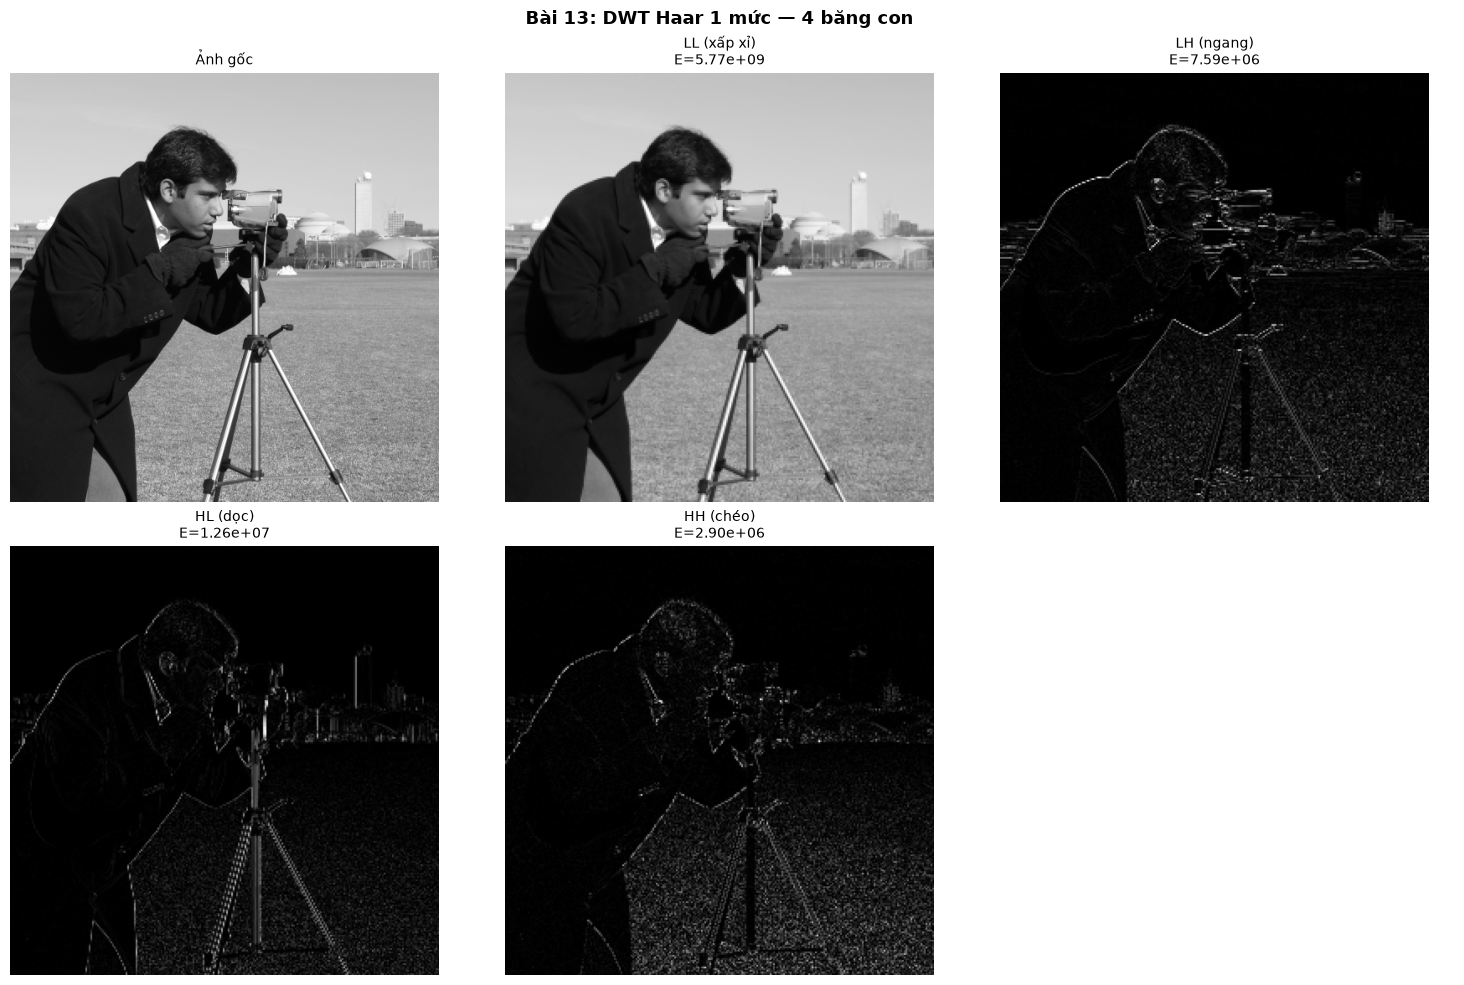

Năng lượng băng LL : 5.7651e+09 (99.60% tổng)
Năng lượng 3 băng còn lại: 0.40%
→ LL tập trung phần lớn năng lượng → chỉ cần giữ LL là đã có ảnh gần đúng

RMSE sau khi ngưỡng hóa 3 băng chi tiết: 5.9419


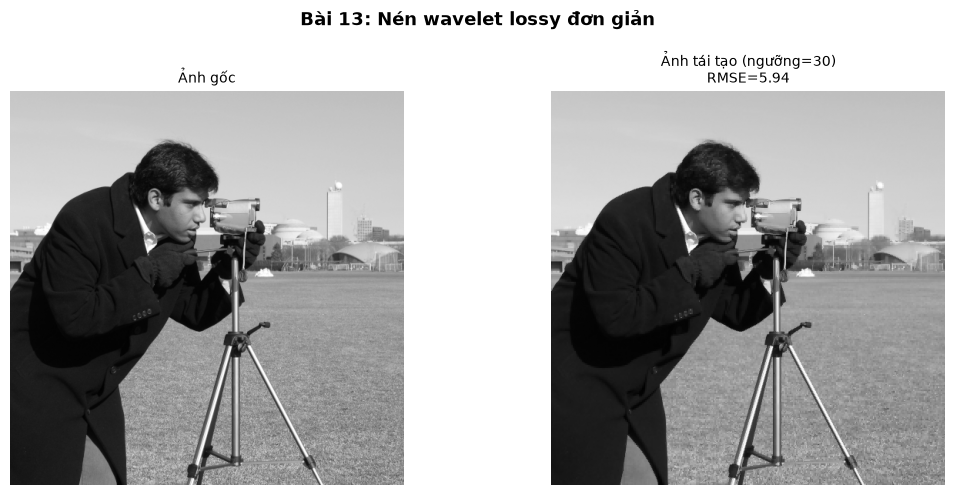

True

In [16]:
# Cài đặt DWT Haar 1 mức (không cần thư viện ngoài)
def dwt_haar_2d(img):
    """DWT Haar 1 mức cho ảnh xám (kích thước chẵn)."""
    M, N = img.shape
    M2, N2 = M // 2, N // 2
    img = img.astype(np.float32)

    # Hàng: lọc thông thấp L và thông cao H
    L = (img[:, 0::2] + img[:, 1::2]) / np.sqrt(2)
    H = (img[:, 0::2] - img[:, 1::2]) / np.sqrt(2)

    # Cột
    LL = (L[0::2, :] + L[1::2, :]) / np.sqrt(2)
    LH = (L[0::2, :] - L[1::2, :]) / np.sqrt(2)
    HL = (H[0::2, :] + H[1::2, :]) / np.sqrt(2)
    HH = (H[0::2, :] - H[1::2, :]) / np.sqrt(2)

    return LL, LH, HL, HH


def idwt_haar_2d(LL, LH, HL, HH):
    """IDWT Haar 1 mức."""
    # Cột
    L = np.zeros((2 * LL.shape[0], LL.shape[1]), dtype=np.float32)
    H = np.zeros_like(L)
    L[0::2, :] = (LL + LH) / np.sqrt(2)
    L[1::2, :] = (LL - LH) / np.sqrt(2)
    H[0::2, :] = (HL + HH) / np.sqrt(2)
    H[1::2, :] = (HL - HH) / np.sqrt(2)

    # Hàng
    img = np.zeros((L.shape[0], 2 * L.shape[1]), dtype=np.float32)
    img[:, 0::2] = (L + H) / np.sqrt(2)
    img[:, 1::2] = (L - H) / np.sqrt(2)
    return img


img = data.camera()
# Cắt cho chẵn
H8, W8 = (img.shape[0] // 2) * 2, (img.shape[1] // 2) * 2
img = img[:H8, :W8]

# 1. DWT
LL, LH, HL, HH = dwt_haar_2d(img)

# 2. Hiển thị 4 băng con
def norm_vis(x):
    return cv2.normalize(np.abs(x), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

show_grid(
    [img, norm_vis(LL), norm_vis(LH), norm_vis(HL), norm_vis(HH)],
    ['Ảnh gốc',
     f'LL (xấp xỉ)\nE={np.sum(LL**2):.2e}',
     f'LH (ngang)\nE={np.sum(LH**2):.2e}',
     f'HL (dọc)\nE={np.sum(HL**2):.2e}',
     f'HH (chéo)\nE={np.sum(HH**2):.2e}'],
    ncols=3, figsize=(15, 10),
    save_path='output/bai13_wavelet.png',
    main_title='Bài 13: DWT Haar 1 mức — 4 băng con'
)

# 3. So sánh năng lượng
E_LL = np.sum(LL**2)
E_total = E_LL + np.sum(LH**2) + np.sum(HL**2) + np.sum(HH**2)
print(f"Năng lượng băng LL : {E_LL:.4e} ({E_LL/E_total*100:.2f}% tổng)")
print(f"Năng lượng 3 băng còn lại: {(E_total - E_LL)/E_total*100:.2f}%")
print("→ LL tập trung phần lớn năng lượng → chỉ cần giữ LL là đã có ảnh gần đúng")

# 4. Nén lossy: giữ LL nguyên, ngưỡng hóa 3 băng chi tiết
threshold = 30
LH_t = np.where(np.abs(LH) > threshold, LH, 0)
HL_t = np.where(np.abs(HL) > threshold, HL, 0)
HH_t = np.where(np.abs(HH) > threshold, HH, 0)

restored = idwt_haar_2d(LL, LH_t, HL_t, HH_t)
restored = np.clip(restored, 0, 255).astype(np.uint8)

rmse = calculate_rmse(img, restored)
print(f"\nRMSE sau khi ngưỡng hóa 3 băng chi tiết: {rmse:.4f}")

show_grid(
    [img, restored],
    ['Ảnh gốc', f'Ảnh tái tạo (ngưỡng={threshold})\nRMSE={rmse:.2f}'],
    ncols=2, figsize=(11, 5),
    save_path='output/bai13_wavelet_reconstruct.png',
    main_title='Bài 13: Nén wavelet lossy đơn giản'
)

cv2.imwrite('output/bai13_LL.png', norm_vis(LL))
cv2.imwrite('output/bai13_restored.png', restored)

**📸 Kết quả:**
- LL chứa phần lớn năng lượng (ảnh xấp xỉ).
- LH/HL/HH chứa chi tiết theo hướng ngang/dọc/chéo.
- Ngưỡng hóa giúp loại bỏ chi tiết nhỏ, tạo hiệu ứng nén lossy mượt mà (không bị blocking như DCT).

---

## Bài 14: So sánh các phương pháp nén

**Mức độ:** Nâng cao

**Mục tiêu:** Tổng hợp, so sánh lossless vs lossy trên cùng một ảnh.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Thực hiện 4 phương pháp:
   - **Lossless:** RLE trên ảnh nhị phân (ngưỡng 128).
   - **Lossy 1:** Lượng tử hóa 4-bit.
   - **Lossy 2:** DCT + lượng tử hóa (pipeline Bài 11, Q-table × 4 để tăng nén).
   - **Lossy 3:** Wavelet + ngưỡng hóa (Bài 13).
3. Đo kích thước sau nén (xấp xỉ) và RMSE/SNR cho mỗi phương pháp.
4. Hiển thị 4 ảnh kết quả + bảng tổng hợp; lưu vào `output/bai14_compare.png`.

**Lời giải:**

Phương pháp              Kích thước (bit)     Tỷ lệ C      RMSE    SNR (dB)
----------------------------------------------------------------------------
Ảnh gốc (8-bit)                2,097,152        1.00      0.00         inf
RLE (nhị phân)                   105,741       19.83     71.61        6.34
Quantize 4-bit                 1,048,576        2.00      8.83       24.53
DCT + Q×4                        160,048       13.10      9.04       24.31
Wavelet + ngưỡng 40              544,696        3.85      6.73       26.88


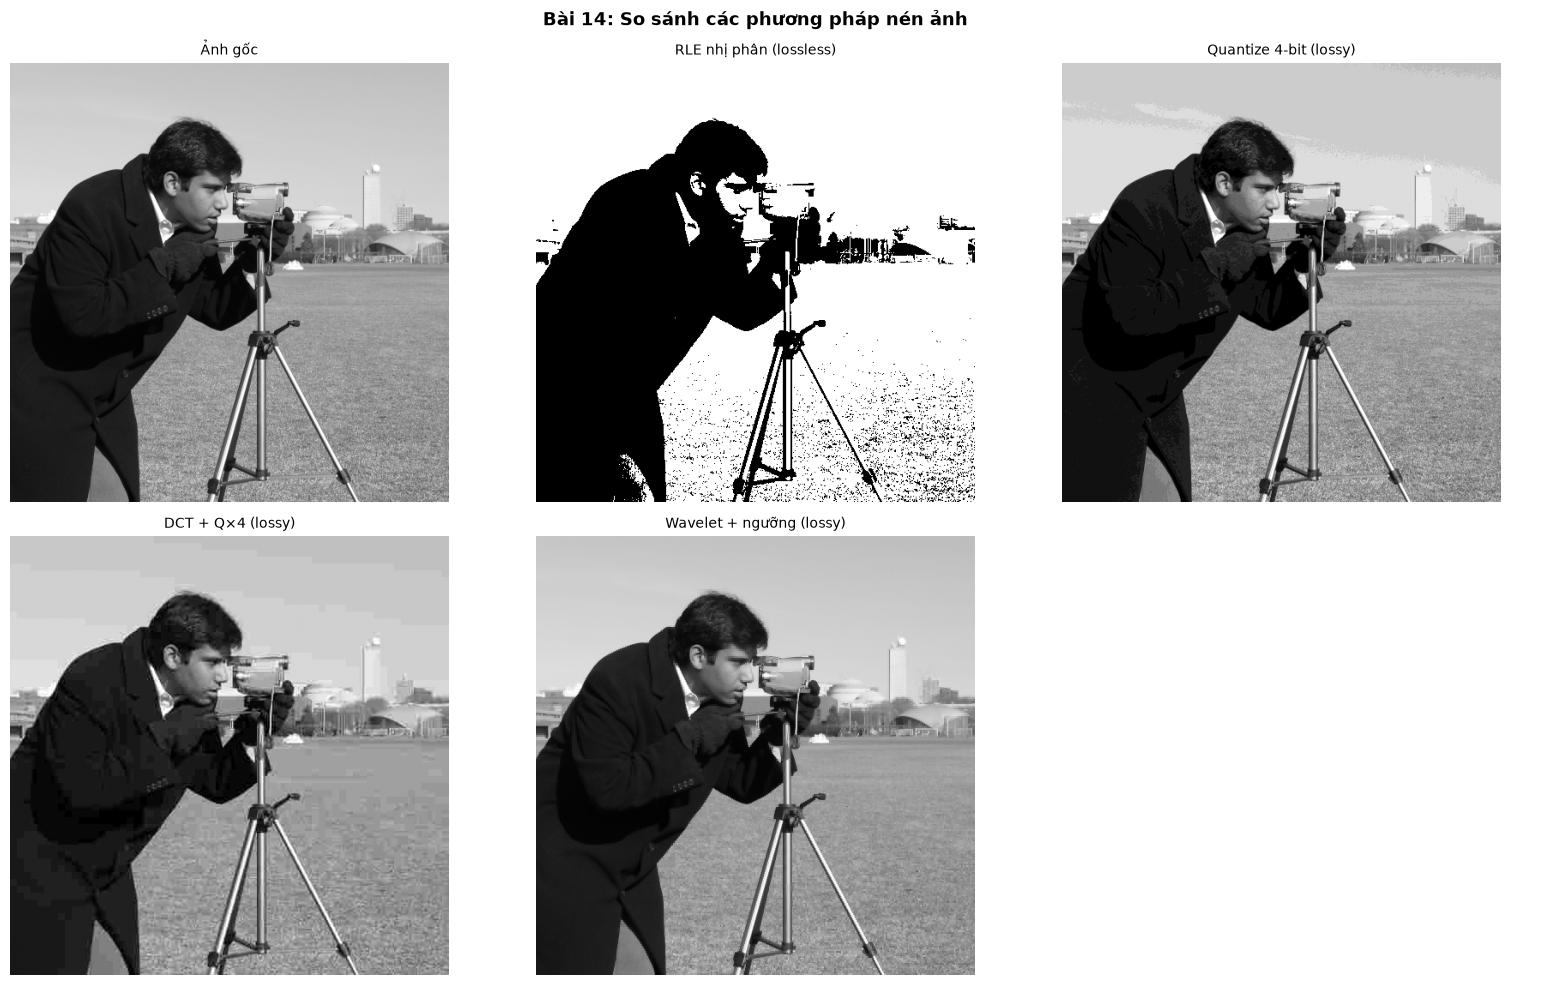

In [17]:
img_full = data.camera()
# Đảm bảo kích thước chia hết cho 8 (DCT) và 2 (DWT)
H8 = (img_full.shape[0] // 8) * 8
W8 = (img_full.shape[1] // 8) * 8
img = img_full[:H8, :W8]

# --- 1. RLE nhị phân ---
binary = (img > 128).astype(np.uint8)
pairs = rle_encode(binary.flatten())
size_rle = len(pairs) * 9        # bit
img_rle = rle_decode(pairs, binary.shape) * 255

# --- 2. Lượng tử hóa 4-bit ---
q4 = quantize_bits(img, 4)
size_q4 = img.size * 4           # bit

# --- 3. DCT + Q-table × 4 ---
Q_base = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)
Q = Q_base * 4

# Áp dụng DCT + Zigzag + cắt EOB (giống Bài 11 nhưng không lưu stream)
coeff_count = 0
for i in range(0, H8, 8):
    for j in range(0, W8, 8):
        block = img[i:i+8, j:j+8].astype(np.float32)
        dct = cv2.dct(block)
        q   = np.round(dct / Q)
        zz  = q.ravel()[zigzag_order]
        nz  = np.nonzero(zz)[0]
        coeff_count += (nz[-1] + 1) if len(nz) > 0 else 0

size_dct = coeff_count * 8    # giả định 8 bit/hệ số

# Tái tạo DCT
img_dct = np.zeros((H8, W8), dtype=np.float32)
for i in range(0, H8, 8):
    for j in range(0, W8, 8):
        block = img[i:i+8, j:j+8].astype(np.float32)
        dct = cv2.dct(block)
        q   = np.round(dct / Q)
        deq = q * Q
        img_dct[i:i+8, j:j+8] = cv2.idct(deq)
img_dct = np.clip(img_dct, 0, 255).astype(np.uint8)

# --- 4. Wavelet + ngưỡng ---
LL, LH, HL, HH = dwt_haar_2d(img)
threshold = 40
LH_t = np.where(np.abs(LH) > threshold, LH, 0)
HL_t = np.where(np.abs(HL) > threshold, HL, 0)
HH_t = np.where(np.abs(HH) > threshold, HH, 0)
img_wav = np.clip(idwt_haar_2d(LL, LH_t, HL_t, HH_t), 0, 255).astype(np.uint8)

nonzero_wav = (np.count_nonzero(LL) + np.count_nonzero(LH_t) +
               np.count_nonzero(HL_t) + np.count_nonzero(HH_t))
size_wav = nonzero_wav * 8

# --- Đo lường ---
def stats(name, comp_img, size_bits, orig):
    mse = np.mean((orig.astype(np.float32) - comp_img.astype(np.float32)) ** 2)
    rmse = np.sqrt(mse)
    snr  = 10 * np.log10(np.mean(orig.astype(np.float32)**2) / mse) if mse > 0 else float('inf')
    C    = (orig.size * 8) / size_bits if size_bits > 0 else float('inf')
    return f"{name:<25}{size_bits:>15,}{C:>12.2f}{rmse:>10.2f}{snr:>12.2f}"

print(f"{'Phương pháp':<25}{'Kích thước (bit)':>15}{'Tỷ lệ C':>12}{'RMSE':>10}{'SNR (dB)':>12}")
print("-" * 76)
print(stats('Ảnh gốc (8-bit)', img, img.size * 8, img))
print(stats('RLE (nhị phân)', img_rle, size_rle, img))
print(stats('Quantize 4-bit', q4, size_q4, img))
print(stats('DCT + Q×4', img_dct, size_dct, img))
print(stats(f'Wavelet + ngưỡng {threshold}', img_wav, size_wav, img))

show_grid(
    [img, img_rle, q4, img_dct, img_wav],
    ['Ảnh gốc',
     'RLE nhị phân (lossless)',
     'Quantize 4-bit (lossy)',
     'DCT + Q×4 (lossy)',
     'Wavelet + ngưỡng (lossy)'],
    ncols=3, figsize=(16, 10),
    save_path='output/bai14_compare.png',
    main_title='Bài 14: So sánh các phương pháp nén ảnh'
)

**📸 Kết quả:** Bảng tổng hợp cho thấy trade-off giữa **tỷ lệ nén** và **chất lượng (RMSE/SNR)**. RLE lossless nhưng tỷ lệ nén thấp; DCT/Wavelet lossy nén mạnh hơn.

---

## 📌 Tổng kết kiến thức được sử dụng

| Bài | Kiến thức Chương 1 + 2 + 3 |
|-----|----------------------------|
| 1 | Entropy, Định lý Shannon |
| 2 | Tỷ lệ nén C, Dư thừa R |
| 3 | RMSE, SNR — đánh giá khách quan |
| 4 | Mã Huffman (lossless) |
| 5 | Mã Golomb & Golomb-Rice |
| 6 | Mã số học (Arithmetic Coding) |
| 7 | Mã LZW |
| 8 | Mã RLE cho ảnh nhị phân |
| 9 | Mã hóa Bit-plane + RLE |
| 10 | Block Transform Coding — DCT 8×8 |
| 11 | Pipeline JPEG (DCT + Zigzag + RLE) |
| 12 | Mã hóa dự đoán DPCM |
| 13 | Biến đổi Wavelet (DWT Haar) |
| 14 | So sánh lossless vs lossy |

**✅ Đặc điểm:**
- Mỗi bài đều có **hiển thị ảnh/biểu đồ minh họa** để sinh viên dễ theo dõi.
- Tất cả kết quả đều **tự động lưu** vào `output/`.
- Chỉ sử dụng kiến thức **Chương 1 + 2 + 3**, không dùng phát hiện biên, phân vùng, hay CV nâng cao.
- Kết hợp kiến thức Chương 1 (bit-plane, histogram) và Chương 2 (biến đổi, lọc) để làm nền cho Chương 3.

Bạn có muốn tôi điều chỉnh gì trước khi gửi **Chương 4** không? 🚀